In [10]:
import json
from pathlib import Path

tax = json.loads(Path("/Users/longquanwen0813/Downloads/timel_taxonomy.json").read_text(encoding="utf-8"))
items = tax["items"]

print("items:", len(items))
print("sample:", items[0])

items: 4660
sample: {'value': 'nature lieu', 'path_ids': ['tm-yhyygbnb']}


In [11]:
from collections import defaultdict

id_to_label = {}      # 节点id -> 法语label
id_to_path = {}       # 节点id -> 任选一条path（足够用来找母标签）

for it in items:
    label = it.get("value")
    path = it.get("path_ids")
    if not isinstance(path, list) or not path:
        continue

    nid = path[-1]
    if isinstance(label, str) and label.strip():
        id_to_label.setdefault(nid, label.strip())

    # 保存一条路径（同一节点可能出现多次；保留第一条即可）
    id_to_path.setdefault(nid, path)

print("nodes with label:", len(id_to_label))
print("nodes with path :", len(id_to_path))

nodes with label: 4576
nodes with path : 4576


In [12]:
parents = set()
children = set()

for it in items:
    path = it.get("path_ids")
    if not isinstance(path, list) or len(path) < 2:
        continue
    for a, b in zip(path[:-1], path[1:]):
        parents.add(a)
        children.add(b)

leaf_ids = sorted(list(children - parents), key=str)  # 出现过作为child但从未当parent
print("leaves =", len(leaf_ids))
print("sample leaves:", leaf_ids[:5])

leaves = 4305
sample leaves: ['tm-22v2fsax', 'tm-23h9wqfr', 'tm-25fjujvw', 'tm-25w3cbz6', 'tm-2645zjsy']


In [13]:
def get_label(nid):
    return id_to_label.get(nid, str(nid))

leaf_to_mother = {}  # leaf_id -> mother_id
leaf_to_mother_label = {}  # leaf_id -> mother_label (FR)

missing = []

for leaf_id in leaf_ids:
    path = id_to_path.get(leaf_id)
    if not path or len(path) < 2:
        missing.append(leaf_id)
        continue

    mother_id = path[1]      # depth=1 ancestor
    leaf_to_mother[leaf_id] = mother_id
    leaf_to_mother_label[leaf_id] = get_label(mother_id)

print("missing mother =", len(missing))
print("example mapping:", leaf_ids[0], "->", leaf_to_mother_label.get(leaf_ids[0]))

missing mother = 0
example mapping: tm-22v2fsax -> Bible


In [14]:
import csv

with open("leaf_to_mother_depth1.csv", "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f)
    w.writerow(["leaf_id", "leaf_label_fr", "mother_id(depth=1)", "mother_label_fr"])
    for leaf_id in leaf_ids:
        w.writerow([
            leaf_id,
            get_label(leaf_id),
            leaf_to_mother.get(leaf_id, ""),
            leaf_to_mother_label.get(leaf_id, "")
        ])

print("written: leaf_to_mother_depth1.csv")

written: leaf_to_mother_depth1.csv


In [15]:
mother_ids = sorted(set(leaf_to_mother.values()), key=str)

with open("mother_classes_depth1.csv", "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f)
    w.writerow(["mother_id(depth=1)", "mother_label_fr"])
    for mid in mother_ids:
        w.writerow([mid, get_label(mid)])

print("mother classes =", len(mother_ids))
print("written: mother_classes_depth1.csv")

mother classes = 70
written: mother_classes_depth1.csv


In [18]:
from collections import defaultdict

# 由 items 重建：nodes + parents/children
nodes = {}
parents_map = defaultdict(set)
children_map = defaultdict(set)

def ensure_node(nid):
    if nid not in nodes:
        nodes[nid] = {"id": nid, "label": None, "parents": [], "children": []}

for it in items:
    path = it.get("path_ids")
    label = it.get("value")

    if not isinstance(path, list) or len(path) == 0:
        continue

    # 确保路径上所有节点存在
    for nid in path:
        ensure_node(nid)

    # 当前节点的 label = value（法语）
    nid = path[-1]
    if isinstance(label, str) and label.strip():
        if nodes[nid]["label"] is None:
            nodes[nid]["label"] = label.strip()

    # 建边：相邻即父子
    for a, b in zip(path[:-1], path[1:]):
        children_map[a].add(b)
        parents_map[b].add(a)

# 收口 parents / children；label 兜底
for nid in nodes:
    nodes[nid]["parents"] = sorted(parents_map.get(nid, set()), key=str)
    nodes[nid]["children"] = sorted(children_map.get(nid, set()), key=str)
    if nodes[nid]["label"] is None:
        nodes[nid]["label"] = str(nid)

roots = [nid for nid, n in nodes.items() if len(n["parents"]) == 0]

print("nodes =", len(nodes))
print("roots =", len(roots), roots[:10])

nodes = 4576
roots = 5 ['tm-yhyygbnb', 'tm-oturfa9i', 'tm-9ygjuwsg', 'tm-rendv4dg', 'tm-y4mebqdz']


depth min/max: 0 7
kept nodes = 75
kept edges = 70


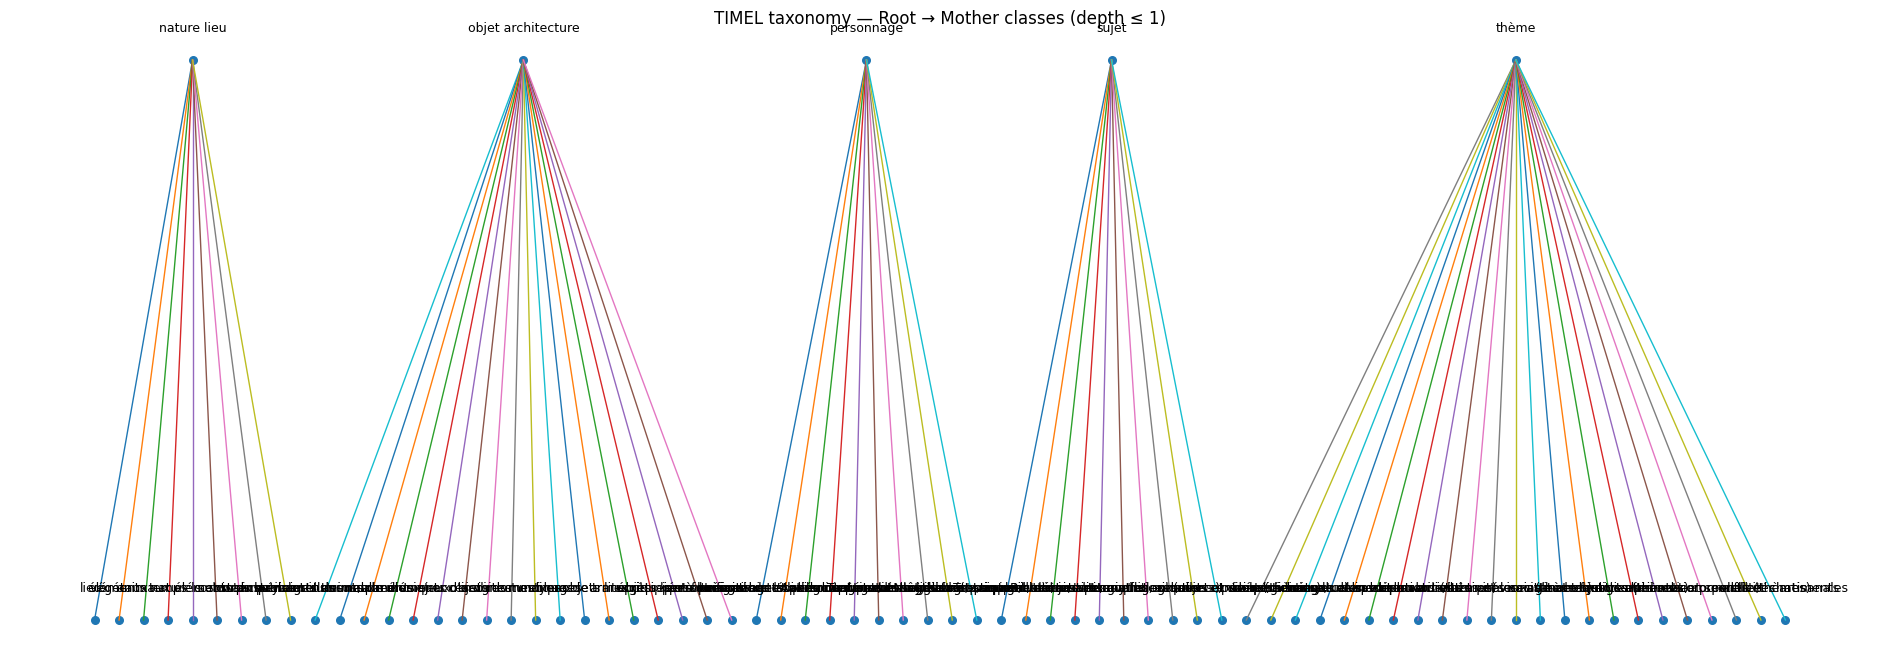

In [21]:
from collections import deque, defaultdict
import matplotlib.pyplot as plt

# 1) depth（最小深度，兼容 DAG）
depth = {nid: None for nid in nodes}
q = deque()

for r in roots:
    depth[r] = 0
    q.append(r)

while q:
    u = q.popleft()
    for v in nodes[u]["children"]:
        cand = depth[u] + 1
        if depth[v] is None or cand < depth[v]:
            depth[v] = cand
            q.append(v)

print("depth min/max:",
      min(d for d in depth.values() if d is not None),
      max(d for d in depth.values() if d is not None))

# 2) 只画 depth<=1
max_depth = 1
keep_nodes = {nid for nid, d in depth.items() if d is not None and d <= max_depth}

sub_children = defaultdict(list)
for nid in keep_nodes:
    for ch in nodes[nid]["children"]:
        if ch in keep_nodes:
            sub_children[nid].append(ch)

print("kept nodes =", len(keep_nodes))
print("kept edges =", sum(len(v) for v in sub_children.values()))

# 3) 布局（简单稳定的树布局）
def compute_tree_layout(roots, children_map, depth, keep_nodes):
    pos = {}
    x_counter = 0

    def dfs(u):
        nonlocal x_counter
        kids = children_map.get(u, [])
        if not kids:
            x = x_counter
            x_counter += 1
            pos[u] = (x, -depth[u])
            return x

        child_xs = [dfs(v) for v in kids]
        x = sum(child_xs) / len(child_xs)
        pos[u] = (x, -depth[u])
        return x

    for r in roots:
        if r in keep_nodes:
            dfs(r)
    return pos

pos = compute_tree_layout(roots, sub_children, depth, keep_nodes)

# 4) 画图（两层都标注法语 label）
plt.figure(figsize=(24, 8))

for u, kids in sub_children.items():
    if u not in pos:
        continue
    x1, y1 = pos[u]
    for v in kids:
        if v in pos:
            x2, y2 = pos[v]
            plt.plot([x1, x2], [y1, y2], linewidth=1)

xs = [pos[n][0] for n in pos]
ys = [pos[n][1] for n in pos]
plt.scatter(xs, ys, s=30)

for n in pos:
    plt.text(pos[n][0], pos[n][1] + 0.05, nodes[n]["label"], fontsize=9, ha="center")

plt.title("TIMEL taxonomy — Root → Mother classes (depth ≤ 1)")
plt.axis("off")
plt.show()

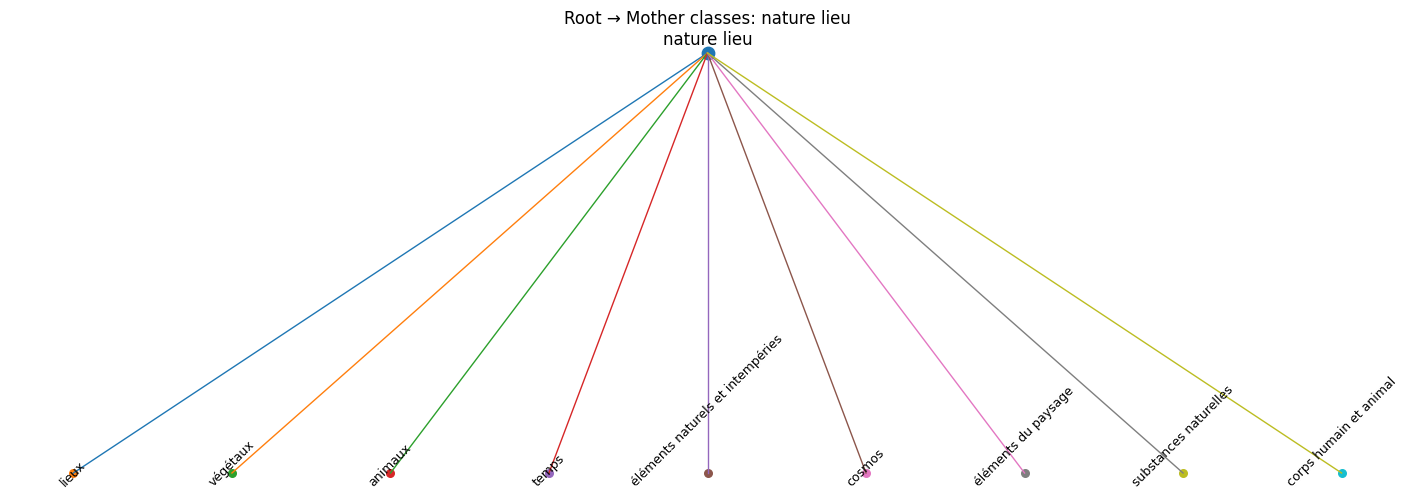

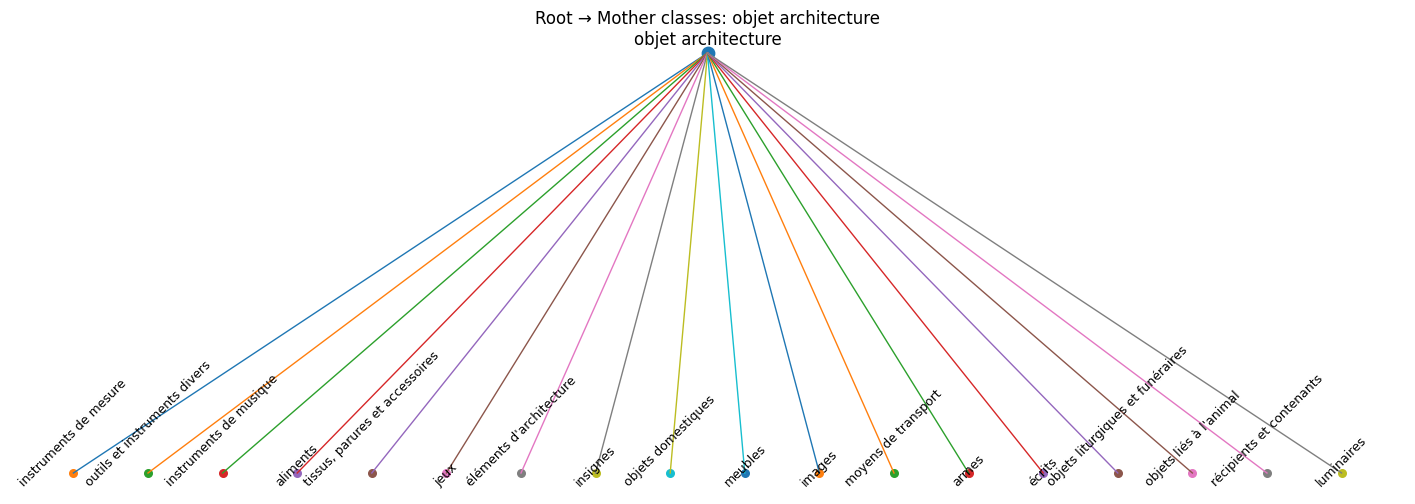

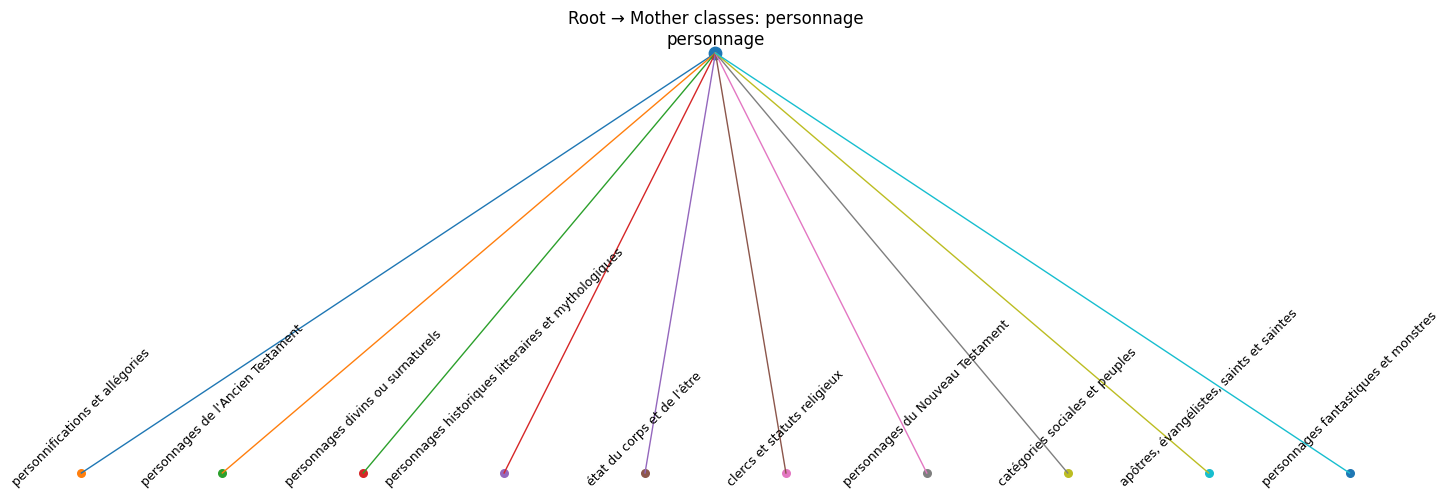

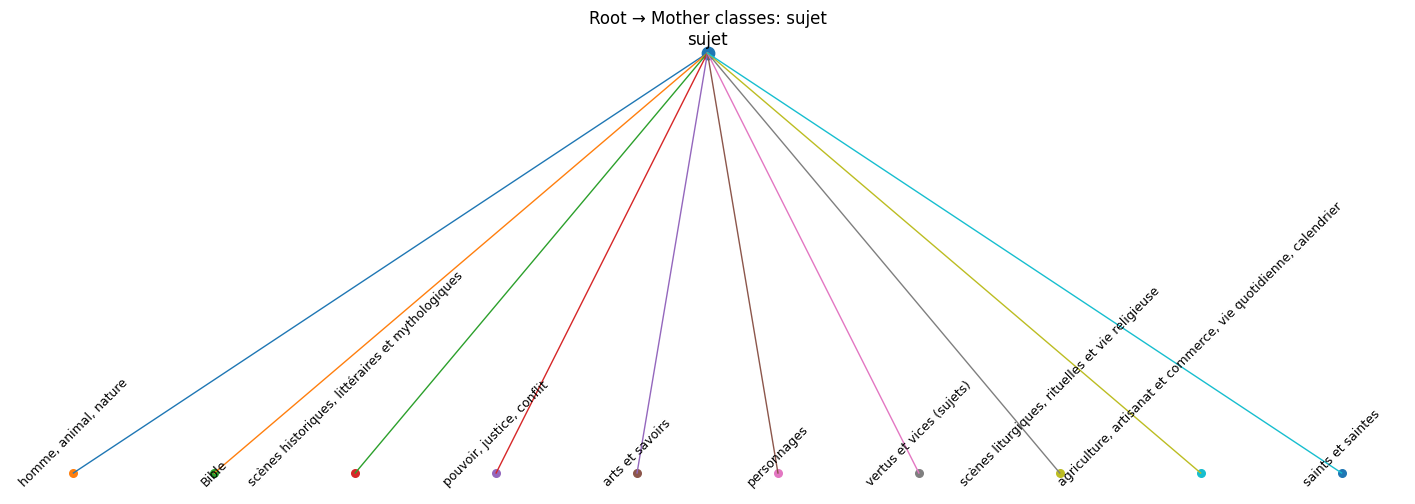

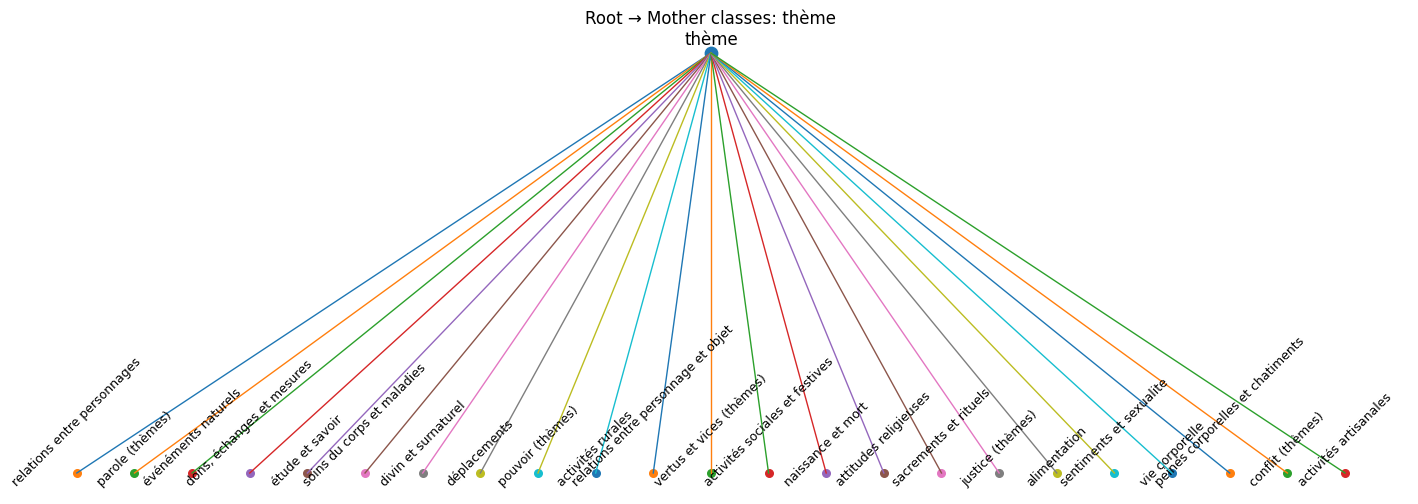

In [22]:
import matplotlib.pyplot as plt
from collections import defaultdict

# root -> children(depth=1) 列表
root_to_mothers = {r: [c for c in sub_children.get(r, []) if depth[c] == 1] for r in roots}

for r in roots:
    mothers = root_to_mothers.get(r, [])
    if not mothers:
        continue

    plt.figure(figsize=(18, 6))

    # 简单布局：root 在中间，mothers 横向排开
    x_root, y_root = 0.5, 1.0
    plt.scatter([x_root], [y_root], s=80)
    plt.text(x_root, y_root + 0.02, nodes[r]["label"], ha="center", fontsize=12)

    xs = [i/(max(1, len(mothers)-1)) for i in range(len(mothers))]
    y_m = 0.0

    for x, m in zip(xs, mothers):
        plt.plot([x_root, x], [y_root, y_m], linewidth=1)
        plt.scatter([x], [y_m], s=30)
        plt.text(x, y_m - 0.03, nodes[m]["label"], ha="center", fontsize=9, rotation=45)

    plt.title(f"Root → Mother classes: {nodes[r]['label']}")
    plt.axis("off")
    plt.show()